# Pipeline Gardenia | Etapa 2: carregar e inspecionar os dados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Anlbp/Projeto-Gardenia-unifeob/blob/main/notebooks/02_carregar_e_inspecionar.ipynb)

Este notebook faz a **primeira leitura dos dados brutos (zona raw)** gerados por `gerador.py`:

1. carrega `clientes`, `produtos` e `compras`;
2. confere se as colunas batem com o dicionário de dados;
3. inspeciona tipos, nulos e valores categóricos;
4. conta quantas anomalias existem em cada tabela (sem corrigir nada ainda);
5. gera os gráficos iniciais.

> **Nada é limpo aqui.** A limpeza (raw → trusted + quarentena) é a Etapa 3.

## Como usar

Na célula de **Configuração**, escolha a fonte dos dados em `FONTE`:

| Valor | O que faz |
|---|---|
| `"github"` | Lê `clientes_N.csv`, `produtos_N.csv` e `compras_N.csv` da pasta `dados/` do repositório (N = `LOTE`). Funciona sem upload. |
| `"upload"` | Você envia `clientes_N.csv`, `produtos_N.csv` e `compras_N.csv` pelo próprio Colab. |
| `"drive"` | Lê os arquivos de uma pasta do Google Drive. |
| `"local"` | Lê os mesmos arquivos da pasta `dados/` do diretório atual (para rodar fora do Colab). |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuração

In [2]:
# ============================ CONFIGURAÇÃO ============================
FONTE = "github"            # "github" | "upload" | "drive" | "local"

# --- usado quando FONTE == "github" ---
GITHUB_USUARIO = "Anlbp"
GITHUB_REPO    = "Projeto-Gardenia-unifeob"
GITHUB_BRANCH  = "main"          # só o nome da branch (NÃO use "tree/main")
PASTA_DADOS    = "dados"    # pasta do repositório com clientes_1.csv, produtos_1.csv, compras_1.csv

# --- usado em "github", "upload", "drive" e "local" ---
LOTE = "1"                  # número do ciclo do gerador (clientes_1.csv, ...)
DRIVE_PASTA = "/content/drive/MyDrive/gardenia"
# =======================================================================

In [3]:
import io
import urllib.error
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

TABELAS = ["clientes", "produtos", "compras"]

if FONTE == "github":
    if "SEU_" in GITHUB_USUARIO or "SEU_" in GITHUB_REPO:
        raise ValueError("Preencha GITHUB_USUARIO e GITHUB_REPO na célula de configuração.")
    branch = GITHUB_BRANCH.removeprefix("tree/")   # tolera o erro comum de colar "tree/main"
    base = f"https://raw.githubusercontent.com/{GITHUB_USUARIO}/{GITHUB_REPO}/{branch}/{PASTA_DADOS}"
    caminhos = {t: f"{base}/{t}_{LOTE}.csv" for t in TABELAS}

elif FONTE == "upload":
    from google.colab import files
    print("Selecione os 3 arquivos: clientes_N.csv, produtos_N.csv e compras_N.csv")
    files.upload()
    caminhos = {t: f"{t}_{LOTE}.csv" for t in TABELAS}

elif FONTE == "drive":
    from google.colab import drive
    drive.mount("/content/drive")
    caminhos = {t: f"{DRIVE_PASTA}/{t}_{LOTE}.csv" for t in TABELAS}

elif FONTE == "local":
    caminhos = {t: f"{PASTA_DADOS}/{t}_{LOTE}.csv" for t in TABELAS}

else:
    raise ValueError('FONTE deve ser "github", "upload", "drive" ou "local".')

for t, c in caminhos.items():
    print(f"{t:10s} <- {c}")

clientes   <- https://raw.githubusercontent.com/Anlbp/Projeto-Gardenia-unifeob/main/dados/clientes_1.csv
produtos   <- https://raw.githubusercontent.com/Anlbp/Projeto-Gardenia-unifeob/main/dados/produtos_1.csv
compras    <- https://raw.githubusercontent.com/Anlbp/Projeto-Gardenia-unifeob/main/dados/compras_1.csv


## 2. Carregar os CSVs

A função tenta vírgula como separador e cai para tabulação se o arquivo vier nesse formato.
Os valores são lidos **como estão**, sem nenhuma correção.

In [4]:
def ler_texto(origem):
    if origem.startswith("http"):
        try:
            with urllib.request.urlopen(origem) as resp:
                return resp.read().decode("utf-8")
        except urllib.error.HTTPError as e:
            raise FileNotFoundError(
                f"Não consegui baixar {origem} (HTTP {e.code}).\n"
                "Confira: (1) GITHUB_USUARIO, GITHUB_REPO e GITHUB_BRANCH (main ou master?); "
                "(2) o repositório é público; "
                "(3) clientes_N.csv, produtos_N.csv e compras_N.csv estão na pasta PASTA_DADOS do repositório (confira LOTE); "
                "(4) a pasta se chama como PASTA_DADOS.\n"
                'Alternativa: troque para FONTE = "upload".'
            ) from None
    with open(origem, encoding="utf-8") as f:
        return f.read()


def ler_csv(origem):
    texto = ler_texto(origem)
    primeira_linha = texto.splitlines()[0]
    sep = "\t" if primeira_linha.count("\t") > primeira_linha.count(",") else ","
    return pd.read_csv(io.StringIO(texto), sep=sep)


clientes = ler_csv(caminhos["clientes"])
produtos = ler_csv(caminhos["produtos"])
compras  = ler_csv(caminhos["compras"])

dados = {"clientes": clientes, "produtos": produtos, "compras": compras}

print(clientes.shape, produtos.shape, compras.shape)
clientes.head()

(5000, 9) (5000, 9) (5000, 10)


,id,nome,email,idade,telefone,cpf,data_nascimento,data_cadastro,inconsistente
0,1,Diego Souza,cliente1@email.com,56.0,abcdefgh,243.853.887-82,1970-08-02,2026-10-09T17:31:44.583642,True
1,2,Bruno Gomes,cliente2@email.com,40.0,(58) 93140-7865,752.441.641-50,2027-10-09,2026-10-09T17:31:44.583642,True
2,3,fernanda gomes,cliente3@email.com,33.0,(23) 99859-2534,544.870.337-60,1993-03-07,2026-10-09T17:31:44.583642,True
3,4,Maria Oliveira,cliente4@email.com,-5.0,(69) 99668-6081,716.877.933-83,1959-09-06,2026-10-09T17:31:44.583642,True
4,5,Diego Silva,cliente5@email.com,71.0,(49) 96675-1102,NaN,1955-02-02,2026-10-09T17:31:44.583642,True


## 3. Conferir as colunas com o dicionário de dados

Se alguma coluna aparecer como faltando ou extra, o dicionário do README e o CSV real divergem. Resolva isso antes de escrever regras de limpeza.

In [5]:
COLUNAS_ESPERADAS = {
    "clientes": ["id", "nome", "email", "idade", "telefone", "cpf",
                 "data_nascimento", "data_cadastro", "inconsistente"],
    "produtos": ["id", "nome", "categoria", "preco", "estoque", "peso",
                 "satisfacao_media", "data_cadastro", "inconsistente"],
    "compras":  ["id", "cliente_id", "produto_id", "quantidade", "valor_total",
                 "desconto", "data_compra", "status", "satisfacao", "inconsistente"],
}

for nome, df in dados.items():
    faltando = set(COLUNAS_ESPERADAS[nome]) - set(df.columns)
    extras = set(df.columns) - set(COLUNAS_ESPERADAS[nome])
    if not faltando and not extras:
        status = "OK"
    else:
        status = f"ATENÇÃO faltando={sorted(faltando)} extras={sorted(extras)}"
    print(f"{nome:10s} {str(df.shape):12s} -> {status}")

clientes   (5000, 9)    -> OK
produtos   (5000, 9)    -> OK
compras    (5000, 10)   -> OK


## 4. Inspeção bruta

Tipos, nulos e a coluna `inconsistente` (marcação interna do gerador, que será removida antes do DW e do K-Means).

Colunas numéricas que aparecem como `object` indicam texto misturado com número (ex.: telefone `abcdefgh`, CPF `11111111111111`).

In [6]:
for nome, df in dados.items():
    print(f"\n=== {nome} ===")
    print(df.dtypes)
    print("\nNulos por coluna:")
    print(df.isna().sum())
    print("\ninconsistente:")
    print(df["inconsistente"].value_counts())


=== clientes ===
id                   int64
nome                object
email               object
idade              float64
telefone            object
cpf                 object
data_nascimento     object
data_cadastro       object
inconsistente         bool
dtype: object

Nulos por coluna:
id                   0
nome                 0
email              590
idade               82
telefone           611
cpf                628
data_nascimento      0
data_cadastro        0
inconsistente        0
dtype: int64

inconsistente:
inconsistente
True    5000
Name: count, dtype: int64

=== produtos ===
id                    int64
nome                 object
categoria            object
preco               float64
estoque               int64
peso                float64
satisfacao_media    float64
data_cadastro        object
inconsistente          bool
dtype: object

Nulos por coluna:
id                    0
nome                295
categoria           208
preco                 0
estoque           

In [7]:
# Primeiras linhas de cada tabela
for nome, df in dados.items():
    print(f"\n=== {nome} ===")
    display(df.head(10))


=== clientes ===


,id,nome,email,idade,telefone,cpf,data_nascimento,data_cadastro,inconsistente
0,1,Diego Souza,cliente1@email.com,56.0,abcdefgh,243.853.887-82,1970-08-02,2026-10-09T17:31:44.583642,True
1,2,Bruno Gomes,cliente2@email.com,40.0,(58) 93140-7865,752.441.641-50,2027-10-09,2026-10-09T17:31:44.583642,True
2,3,fernanda gomes,cliente3@email.com,33.0,(23) 99859-2534,544.870.337-60,1993-03-07,2026-10-09T17:31:44.583642,True
3,4,Maria Oliveira,cliente4@email.com,-5.0,(69) 99668-6081,716.877.933-83,1959-09-06,2026-10-09T17:31:44.583642,True
4,5,Diego Silva,cliente5@email.com,71.0,(49) 96675-1102,NaN,1955-02-02,2026-10-09T17:31:44.583642,True
5,6,Fernanda Rodrigues,cliente6email.com,18.0,(38) 93114-8010,552.203.155-68,2007-11-14,2026-10-09T17:31:44.583642,True
6,7,carlos ferreira,cliente7@email.com,65.0,(82) 99564-6548,621.956.163-28,1961-03-01,2026-10-09T17:31:44.583642,True
7,8,João Almeida,cliente8@email.com,49.0,(43) 97775-2689,11111111111111,1977-01-18,2026-10-09T17:31:44.583642,True
8,9,João Oliveira,cliente9@email.com,61.0,(95) 97367-7033,285.963.736-65,2027-10-09,2026-10-09T17:31:44.583642,True
9,10,Diego Costa,cliente10@email.com,71.0,(49) 92263-3853,123,1954-10-31,2026-10-09T17:31:44.583642,True



=== produtos ===


,id,nome,categoria,preco,estoque,peso,satisfacao_media,data_cadastro,inconsistente
0,1,Sofá Plus,Livros,589.74,253,10.35,100.0,2026-10-09T17:31:44.583642,True
1,2,sMartpHone PreMIUm,Esportes,624.32,60,44.78,2.1,2026-10-09T17:31:44.583642,True
2,3,ARROZ PRO,Alimentos,640.04,59,0.22,1.3,2026-10-09T17:31:44.583642,True
3,4,Ursinho Premium,Casa,97.11,336,22.20,NaN,2026-10-09T17:31:44.583642,True
4,5,Smartphone Max,Brinquedos,429.62,-75,7.59,0.5,2026-10-09T17:31:44.583642,True
5,6,BOLA MAX,Roupas,568.01,315,42.58,4.4,2026-10-09T17:31:44.583642,True
6,7,Sofá Max,Brinquedos,0.00,302,47.35,4.7,2026-10-09T17:31:44.583642,True
7,8,Feijão Plus,Roupas,377.21,-45,29.97,1.3,2026-10-09T17:31:44.583642,True
8,9,AVENTURA PREMIUM,Roupas,36.18,26,1.99,0.1,2026-10-09T17:31:44.583642,True
9,10,Notebook max,Eletrônicos,12.29,0,22.77,0.1,2026-10-09T17:31:44.583642,True



=== compras ===


,id,cliente_id,produto_id,quantidade,valor_total,desconto,data_compra,status,satisfacao,inconsistente
0,1,138,3460,6,1486.18,218.40,2025-11-04T17:31:44.583642,cancelado,2.0,True
1,2,1272,1496,3,3630.24,862.48,2026-05-29T17:31:44.583642,cancelado,-1.0,True
2,3,160,874,-10,3974.36,998.11,2026-02-01T17:31:44.583642,entregue,4.0,True
3,4,3035,855,8,3108.68,452.97,2026-02-15T17:31:44.583642,Entregue,4.0,True
4,5,3251,3991,2,1530.60,13.92,2027-10-09T17:31:44.707915,enviado,3.0,True
5,6,907,4499,8,-547.34,99.67,2026-05-01T17:31:44.583642,pendente,3.0,True
6,7,2308,3582,3,273.16,37.27,2026-06-14T17:31:44.583642,CaNCelaDO,5.0,True
7,8,99841,1094,1,2375.29,70.03,2026-07-30T17:31:44.583642,pago,5.0,True
8,9,1555,2539,1,2138.25,587.06,2026-06-28T17:31:44.583642,eNvIAdO,5.0,True
9,10,1268,92137,5,1776.68,263.38,2026-07-01T17:31:44.583642,pendente,3.0,True


In [8]:
# Estatísticas descritivas das colunas numéricas (olhe os mínimos e máximos)
for nome, df in dados.items():
    print(f"\n=== {nome} ===")
    display(df.drop(columns=["inconsistente"]).describe().T)


=== clientes ===


,count,mean,std,min,25%,50%,75%,max
id,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
idade,4918.0,52.880643,33.139750,-5.0,33.00,50.0,67.00,200.0



=== produtos ===


,count,mean,std,min,25%,50%,75%,max
id,5000.0,2500.500000,1443.520003,1.00,1250.7500,2500.500,3750.2500,5000.00
preco,5000.0,403.089212,327.482646,-99.44,94.8150,389.545,690.6725,999.97
estoque,5000.0,224.471000,162.857184,-100.00,88.0000,229.000,364.0000,500.00
peso,5000.0,22.131548,16.274962,-9.98,8.5375,22.285,36.1300,50.00
satisfacao_media,4919.0,4.489978,13.314931,-1.00,1.3000,2.600,4.0000,100.00



=== compras ===


,count,mean,std,min,25%,50%,75%,max
id,5000.0,2500.500000,1443.520003,1.00,1250.7500,2500.500,3750.250,5000.00
cliente_id,5000.0,10320.909200,25767.176277,1.00,1394.0000,2719.000,4093.000,99977.00
produto_id,5000.0,10928.876000,26672.515720,1.00,1359.0000,2735.500,4105.250,99993.00
quantidade,5000.0,4.623200,4.216062,-10.00,2.0000,5.000,8.000,10.00
valor_total,5000.0,2049.303874,1656.235423,-997.41,497.8750,1990.265,3479.835,4996.91
desconto,5000.0,352.185080,316.788667,0.02,119.3525,240.875,526.345,1474.62
satisfacao,4924.0,4.664907,12.301605,-1.00,2.0000,3.000,4.000,100.00


In [9]:
# Valores categóricos exatamente como aparecem (caixa, typos, categorias inexistentes)
print("--- produtos.categoria ---")
print(produtos["categoria"].value_counts(dropna=False))

print("\n--- compras.status ---")
print(f"{compras['status'].nunique()} variações distintas (caixa misturada). Contagem após strip + lower:")
print(compras["status"].str.strip().str.lower().value_counts(dropna=False))

--- produtos.categoria ---
categoria
Brinquedos               682
Roupas                   660
Alimentos                659
Esportes                 655
Eletrônicos              638
Casa                     628
Livros                   627
NaN                      208
123                      125
Categoria Inexistente    118
Name: count, dtype: int64

--- compras.status ---
321 variações distintas (caixa misturada). Contagem após strip + lower:
status
cancelado    970
enviado      953
entregue     929
pendente     923
pago         920
canceladu     28
canceldo      25
entregu       24
etregue       23
pedente       22
paguo         22
pago0         21
cacelado      21
entrege       21
enviadio      19
pndente       18
envado        18
pendnete      16
pago.         14
enviiado      13
Name: count, dtype: int64


## 5. Diagnóstico de anomalias (somente contagem)

Cada linha abaixo é uma **regra de qualidade** com a quantidade de registros que a violam. Isso serve de base para as regras de limpeza da Etapa 3.

Premissas usadas (ajuste se o seu gerador for diferente):

- idade válida: 18 a 100 anos;
- `satisfacao_media` válida: 0 a 5; `satisfacao` da compra válida: 1 a 5;
- status válidos: `pendente`, `pago`, `enviado`, `entregue`, `cancelado`;
- datas futuras (depois de hoje) são inválidas.

**Atenção às regras `FK:`** (integridade referencial). Com os arquivos de *exemplo* (só as primeiras 200 linhas), muitos `cliente_id`/`produto_id` não existem nas tabelas de exemplo. Isso é esperado. Elas só fazem sentido com o lote completo.

In [10]:
agora = pd.Timestamp.now()

REGEX_EMAIL = r"^[\w.+-]+@[\w-]+\.[\w.-]+$"
REGEX_TEL   = r"^\(\d{2}\) \d{5}-\d{4}$"
REGEX_CPF   = r"^\d{3}\.\d{3}\.\d{3}-\d{2}$"
CATEGORIAS_VALIDAS = {"Alimentos", "Brinquedos", "Casa", "Eletrônicos",
                      "Esportes", "Livros", "Roupas"}
STATUS_VALIDOS = {"pendente", "pago", "enviado", "entregue", "cancelado"}


def num(s):
    return pd.to_numeric(s, errors="coerce")


def data(s):
    return pd.to_datetime(s, errors="coerce")


def vazio(s):
    return s.isna() | (s.astype(str).str.strip() == "")


def formato_invalido(s, regex):
    return s.notna() & ~s.astype(str).str.match(regex)


def caixa_produto_ok(nome):
    return all(p == p.capitalize() or p == "TV" for p in str(nome).split())


regras = []


def regra(tabela, coluna, descricao, mascara):
    mascara = mascara.fillna(False).astype(bool)
    regras.append({
        "tabela": tabela,
        "coluna": coluna,
        "regra": descricao,
        "qtd": int(mascara.sum()),
        "pct": round(100 * mascara.mean(), 1),
    })


# ----------------------------- clientes -----------------------------
c = clientes
regra("clientes", "nome", "ausente/vazio", vazio(c["nome"]))
regra("clientes", "nome", "caixa fora do padrão (Title Case)",
      c["nome"].notna() & (c["nome"].astype(str) != c["nome"].astype(str).str.strip().str.title()))
regra("clientes", "email", "ausente", c["email"].isna())
regra("clientes", "email", "formato inválido (ex.: sem @)", formato_invalido(c["email"], REGEX_EMAIL))
regra("clientes", "telefone", "ausente", c["telefone"].isna())
regra("clientes", "telefone", "formato inválido", formato_invalido(c["telefone"], REGEX_TEL))
regra("clientes", "cpf", "ausente", c["cpf"].isna())
regra("clientes", "cpf", "formato inválido", formato_invalido(c["cpf"], REGEX_CPF))
regra("clientes", "idade", "ausente", c["idade"].isna())
regra("clientes", "idade", "fora de 18-100", num(c["idade"]).notna() & ~num(c["idade"]).between(18, 100))
regra("clientes", "data_nascimento", "ilegível", c["data_nascimento"].notna() & data(c["data_nascimento"]).isna())
regra("clientes", "data_nascimento", "no futuro", data(c["data_nascimento"]) > agora)

# ----------------------------- produtos -----------------------------
p = produtos
regra("produtos", "nome", "ausente/vazio", vazio(p["nome"]))
regra("produtos", "nome", "caixa fora do padrão",
      p["nome"].notna() & ~p["nome"].astype(str).map(caixa_produto_ok))
regra("produtos", "categoria", "ausente/vazia", vazio(p["categoria"]))
regra("produtos", "categoria", "fora da lista válida",
      ~vazio(p["categoria"]) & ~p["categoria"].isin(CATEGORIAS_VALIDAS))
regra("produtos", "preco", "<= 0", num(p["preco"]) <= 0)
regra("produtos", "estoque", "negativo", num(p["estoque"]) < 0)
regra("produtos", "peso", "<= 0", num(p["peso"]) <= 0)
regra("produtos", "satisfacao_media", "ausente", p["satisfacao_media"].isna())
regra("produtos", "satisfacao_media", "fora de 0-5",
      num(p["satisfacao_media"]).notna() & ~num(p["satisfacao_media"]).between(0, 5))

# ----------------------------- compras ------------------------------
k = compras
status_norm = k["status"].astype(str).str.strip().str.lower()
regra("compras", "quantidade", "<= 0", num(k["quantidade"]) <= 0)
regra("compras", "valor_total", "<= 0", num(k["valor_total"]) <= 0)
regra("compras", "desconto", "negativo", num(k["desconto"]) < 0)
regra("compras", "desconto", "maior que valor_total", num(k["desconto"]) > num(k["valor_total"]))
regra("compras", "data_compra", "ilegível", k["data_compra"].notna() & data(k["data_compra"]).isna())
regra("compras", "data_compra", "no futuro", data(k["data_compra"]) > agora)
regra("compras", "status", "caixa/espaços fora do padrão", k["status"].notna() & (k["status"] != status_norm))
regra("compras", "status", "valor inexistente (mesmo após lower)",
      k["status"].notna() & ~status_norm.isin(STATUS_VALIDOS))
regra("compras", "satisfacao", "fora de 1-5",
      num(k["satisfacao"]).notna() & ~num(k["satisfacao"]).between(1, 5))
regra("compras", "cliente_id", "FK: não existe em clientes",
      k["cliente_id"].notna() & ~k["cliente_id"].isin(clientes["id"]))
regra("compras", "produto_id", "FK: não existe em produtos",
      k["produto_id"].notna() & ~k["produto_id"].isin(produtos["id"]))

diagnostico = pd.DataFrame(regras)
display(
    diagnostico[diagnostico["qtd"] > 0]
    .sort_values(["tabela", "pct"], ascending=[True, False])
    .reset_index(drop=True)
)

,tabela,coluna,regra,qtd,pct
0,clientes,nome,caixa fora do padrão (Title Case),1836,36.7
1,clientes,email,formato inválido (ex.: sem @),760,15.2
2,clientes,cpf,ausente,628,12.6
3,clientes,telefone,ausente,611,12.2
4,clientes,email,ausente,590,11.8
5,clientes,data_nascimento,no futuro,432,8.6
6,clientes,idade,fora de 18-100,383,7.7
7,clientes,cpf,formato inválido,294,5.9
8,clientes,telefone,formato inválido,262,5.2
9,clientes,idade,ausente,82,1.6


## 6. Gráficos iniciais

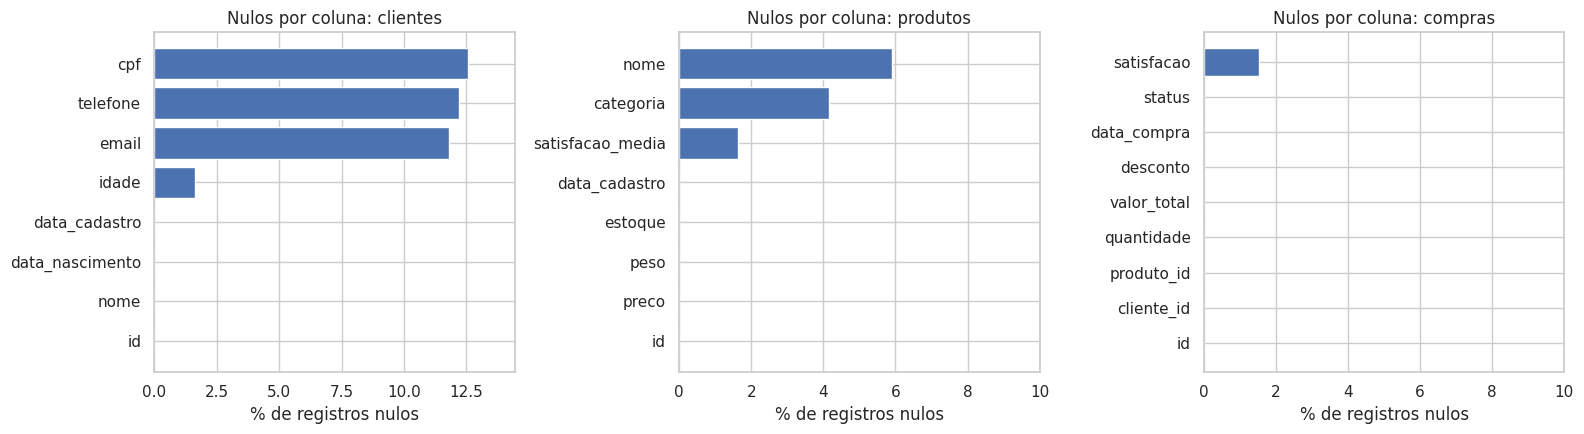

In [11]:
# 6.1 Percentual de nulos por coluna
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nome, df) in zip(eixos, dados.items()):
    pct_nulos = (df.drop(columns=["inconsistente"]).isna().mean() * 100).sort_values()
    ax.barh(pct_nulos.index, pct_nulos.values, color="#4C72B0")
    ax.set_title(f"Nulos por coluna: {nome}")
    ax.set_xlabel("% de registros nulos")
    ax.set_xlim(0, max(10, pct_nulos.max() * 1.15))
plt.tight_layout()
plt.show()

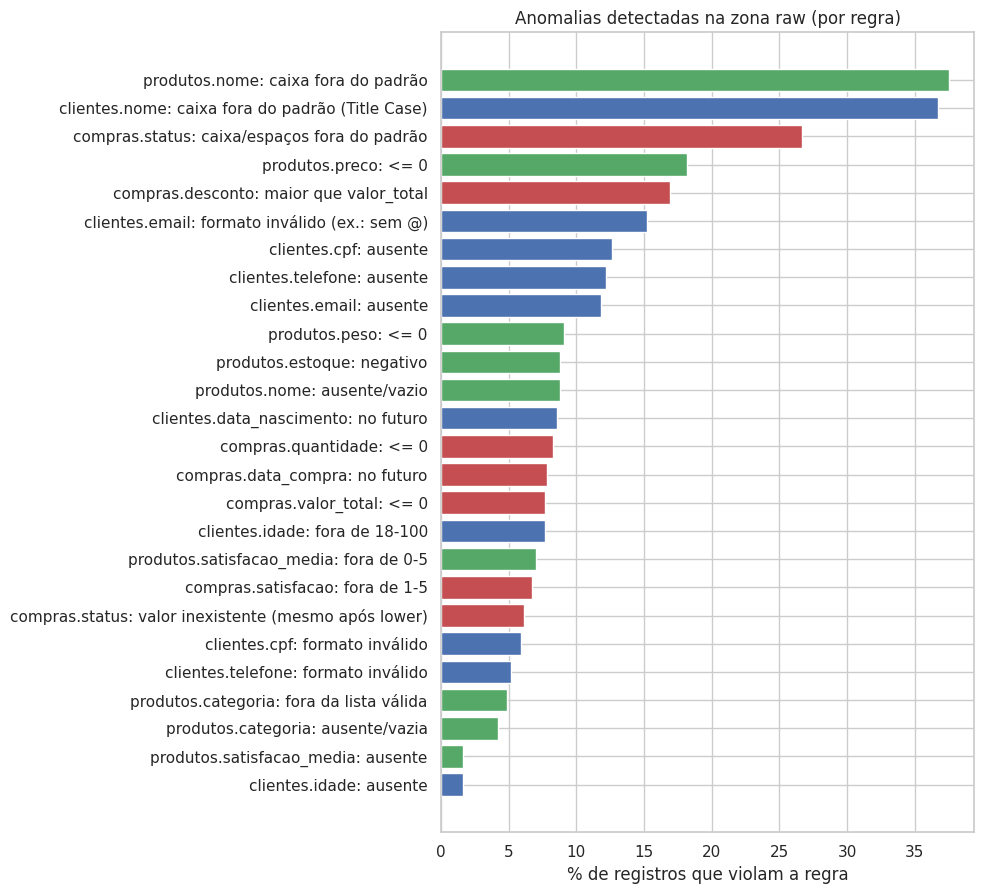

In [12]:
# 6.2 Regras de qualidade mais violadas (exclui FK, que depende do lote completo)
graf = diagnostico[(diagnostico["qtd"] > 0) & ~diagnostico["regra"].str.startswith("FK")].copy()
graf["rotulo"] = graf["tabela"] + "." + graf["coluna"] + ": " + graf["regra"]
graf = graf.sort_values("pct")

if graf.empty:
    print("Nenhuma anomalia encontrada (base limpa).")
else:
    cores = graf["tabela"].map({"clientes": "#4C72B0", "produtos": "#55A868", "compras": "#C44E52"})
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(graf))))
    ax.barh(graf["rotulo"], graf["pct"], color=cores)
    ax.set_title("Anomalias detectadas na zona raw (por regra)")
    ax.set_xlabel("% de registros que violam a regra")
    plt.tight_layout()
    plt.show()

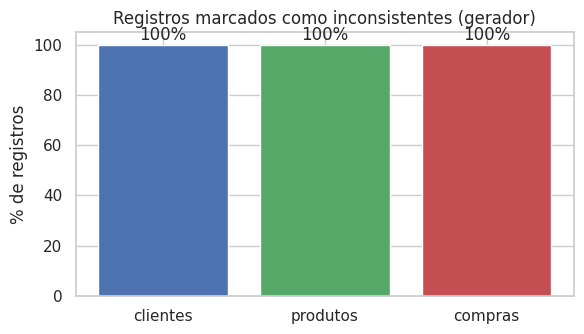

In [13]:
# 6.3 Proporção de registros marcados como inconsistentes pelo gerador
prop = pd.Series({
    nome: (df["inconsistente"].astype(str).str.lower() == "true").mean() * 100
    for nome, df in dados.items()
})

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(prop.index, prop.values, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Registros marcados como inconsistentes (gerador)")
ax.set_ylabel("% de registros")
ax.set_ylim(0, 105)
for i, v in enumerate(prop.values):
    ax.text(i, v + 2, f"{v:.0f}%", ha="center")
plt.tight_layout()
plt.show()

In [20]:
%pip install -q -U google-genai

import os
from IPython.display import Markdown, display

# A chave fica nos "Secrets" do Colab (ícone de chave na barra lateral), nunca no código
try:
    from google.colab import userdata
    CHAVE = userdata.get("GEMINI_API_KEY")
except Exception:
    CHAVE = os.environ.get("GEMINI_API_KEY")

if not CHAVE:
    print("Sem GEMINI_API_KEY: pulando a interpretação por IA.")
else:
    from google import genai

    # Só estatísticas agregadas vão para a IA, nunca os registros (CPF, e-mail etc.)
    formas = {n: d.shape for n, d in dados.items()}
    nulos = pd.concat({
        nome: df.drop(columns=["inconsistente"]).isna().mean().mul(100).round(1)
        for nome, df in dados.items()
    })
    anomalias = diagnostico[diagnostico["qtd"] > 0].sort_values(["tabela", "pct"], ascending=[True, False])

    prompt = f"""Você é um analista de dados sênior revisando a zona raw de um projeto de Data Warehouse (e-commerce).
Com base APENAS nos números abaixo, escreva a interpretação em português, em 2 a 3 parágrafos curtos:
1) quais colunas têm mais nulos; 2) quais regras são mais violadas; 3) o que isso sugere para a limpeza
(o que corrigir, o que anular e o que mandar para quarentena).
Não invente números que não estejam nos dados. As regras "FK" só fazem sentido com o lote completo.

TAMANHO DAS TABELAS: {formas}

% DE NULOS POR COLUNA:
{nulos.to_string()}

ANOMALIAS POR REGRA (qtd e % de registros que violam):
{anomalias.to_string(index=False)}

% MARCADO COMO INCONSISTENTE PELO GERADOR: {prop.round(1).to_dict()}
"""

    client = genai.Client(api_key=CHAVE)
    resp = client.models.generate_content(model="gemini-3.8-flash", contents=prompt)
    display(Markdown("### Interpretação (gerada por IA)\n\n" + resp.text))

### Interpretação (gerada por IA)

Na zona raw, as colunas com maior proporção de valores nulos concentram-se na tabela de clientes: `cpf` (12,6%), `telefone` (12,2%) e `email` (11,8%), seguidas em menor escala por `nome` (5,9%) e `categoria` (4,2%) em produtos. Em relação às anomalias, as regras mais violadas envolvem desvios de formatação de texto, lideradas por `nome` de produtos fora da caixa padrão (37,5%), `nome` de clientes fora de Title Case (36,7%) e `status` de compras com caixa/espaços incorretos (26,7%). No campo das regras de negócio, destacam-se `preco` de produtos menor ou igual a zero (18,2%), `desconto` superior ao valor total em compras (16,9%) e `email` de clientes com formato inválido (15,2%).

Para a estratégia de limpeza e tratamento, deve-se **corrigir** automaticamente os problemas de padronização sintática (espaços extras e ajuste de caixa alta/baixa nos nomes e status, que chegam a 37,5% dos casos). Sugere-se **anular** (substituir por nulo) atributos complementares com inconsistências pontuais que não inviabilizam o registro principal, como contatos com formato inválido (15,2% dos emails e 5,2% dos telefones), notas de satisfação fora da escala de 1 a 5 (6,7% em compras e 7,0% em produtos) e idades fora da faixa de 18-100 (7,7%). 

Por fim, devem ser encaminhados para a **quarentena** os registros que comprometem a consistência financeira, temporal e relacional do DW: produtos com preço menor ou igual a zero (18,2%), compras com desconto maior que o valor total (16,9%), transações com quantidade menor ou igual a zero (8,3%), datas de compra e nascimento no futuro (7,8% e 8,6%), além das compras com quebra de integridade referencial nas FKs de `produto_id` (9,1%) e `cliente_id` (8,5%), avaliadas no contexto do lote completo.

## 7. Interpretação

*Escreva aqui 2 ou 3 frases com o que os gráficos mostram, por exemplo: quais colunas têm mais nulos, quais regras são mais violadas e o que isso sugere para a limpeza.*

## Próximos passos

**Etapa 3: EDA + limpeza.** Transformar `raw` em `trusted` + `quarentena`, usando as regras acima como ponto de partida (cada regra vira correção, anulação ou envio para quarentena com `motivo_rejeicao`).